### SVM (Support Vector Machine) is used to find the optimal hyperplane that separates classes with maximum margin. It is effective in high-dimensional spaces.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../PHASE-1/Data/heart_cleaned.csv")

df.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1


##### The dataset is divided into input features (X) and the target variable (HeartDisease). The target variable represents whether a patient has heart disease (1) or not (0).

In [4]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

##### The dataset is split into training and testing sets in an 80:20 ratio. The training set is used to train the model, while the testing set evaluates its performance on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
#FEATURE SELECTION
svm = SVC(kernel='linear', probability=True)

selector = SequentialFeatureSelector(
    svm,
    n_features_to_select=5,
    direction='forward',
    cv=5
)

selector.fit(X_train_scaled, y_train)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'ST_Slope_Up'], dtype='str')


In [8]:
# use of selected feature
X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

scaler_sel = StandardScaler()

X_train_sel = scaler_sel.fit_transform(X_train_sel)
X_test_sel = scaler_sel.transform(X_test_sel)


In [10]:
#Training SVM   model 
model = SVC(probability=True)
model.fit(X_train_sel, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
y_pred = model.predict(X_test_sel)

- The SVM model achieves an accuracy of 79.3%. 
- It performs well in capturing complex relationships in the dataset due to the use of a non-linear kernel.

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

roc = roc_auc_score(y_test, model.predict_proba(X_test_sel)[:,1])
print("ROC AUC:", roc)

Accuracy: 0.7934782608695652
Precision: 0.8631578947368421
Recall: 0.7663551401869159
F1 Score: 0.8118811881188119
ROC AUC: 0.837237528826314


##### The confusion matrix shows the classification performance of the SVM model, including correctly predicted cases and misclassifications.

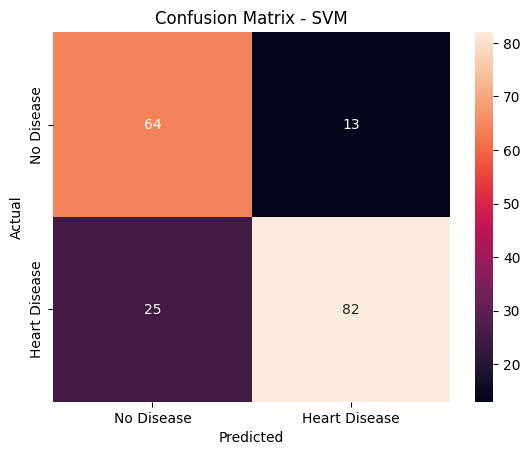

In [14]:
cm = confusion_matrix(y_test, y_pred)

labels = ["No Disease", "Heart Disease"]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")
plt.show()


##### The ROC curve demonstrates the model’s ability to distinguish between classes. A higher AUC value indicates better classification performance.

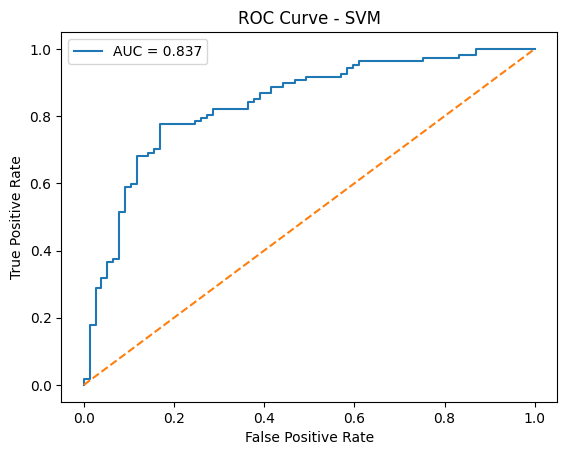

In [15]:
y_prob = model.predict_proba(X_test_sel)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [16]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    cv=5
)

grid.fit(X_train_sel, y_train)

print("Best Parameters:", grid.best_params_)

best_svm = grid.best_estimator_

Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}


- The optimal SVM parameters indicate that the dataset is not linearly separable, as the RBF kernel was selected. A low value of C (0.1) suggests that the model prioritizes generalization and allows some misclassifications to avoid overfitting.
- The gamma parameter set to 'scale' ensures an appropriate balance in the influence of individual data points.
- Overall, the selected parameters result in a smooth and flexible decision boundary that generalizes well to unseen data.

In [17]:
y_pred_best = best_svm.predict(X_test_sel)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))

Final Accuracy: 0.7989130434782609
